In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)
n_borrowers = 2500

# Borrower attributes
annual_income = np.random.normal(75000, 25000, n_borrowers).clip(20000, 200000)
loan_amount = np.random.normal(25000, 10000, n_borrowers).clip(5000, 60000)
debt_to_income = (np.random.beta(2, 5, n_borrowers) * 60).round(2)
delinquencies_2yr = np.random.poisson(0.4, n_borrowers)
revolving_utilization = np.random.uniform(0.05, 0.95, n_borrowers)

df_credit = pd.DataFrame({
    'Borrower_ID': [f'LN-{i:05d}' for i in range(1, n_borrowers + 1)],
    'Annual_Income': annual_income.round(2),
    'Loan_Amount': loan_amount.round(2),
    'DTI_Ratio': debt_to_income,
    'Delinquencies_2Yr': delinquencies_2yr,
    'Revolving_Util': revolving_utilization.round(3)
})

# Basel Default Trigger Probability (Log-odds function)
z = (
    -3.2
    + 0.04 * df_credit['DTI_Ratio']
    + 0.85 * df_credit['Delinquencies_2Yr']
    + 1.6 * df_credit['Revolving_Util']
    - 0.000015 * df_credit['Annual_Income']
)
pd_actual = 1 / (1 + np.exp(-z))
df_credit['Default_Flag'] = (np.random.rand(n_borrowers) < pd_actual).astype(int)

print(f"Total Loans: {len(df_credit)} | Default Rate: {df_credit['Default_Flag'].mean():.2%}")
df_credit.head()

Total Loans: 2500 | Default Rate: 10.04%


,Borrower_ID,Annual_Income,Loan_Amount,DTI_Ratio,Delinquencies_2Yr,Revolving_Util,Default_Flag
0,LN-00001,87417.85,30706.13,14.32,0,0.067,0
1,LN-00002,71543.39,34681.85,32.20,0,0.375,0
2,LN-00003,91192.21,21686.92,10.13,0,0.067,0
3,LN-00004,113075.75,18877.63,25.32,1,0.947,0
4,LN-00005,69146.17,14148.49,19.59,1,0.160,0


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, brier_score_loss, classification_report
from sklearn.preprocessing import StandardScaler

X = df_credit[['Annual_Income', 'Loan_Amount', 'DTI_Ratio', 'Delinquencies_2Yr', 'Revolving_Util']]
y = df_credit['Default_Flag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit Logistic Regression for regulatory-explainable PD
credit_model = LogisticRegression(solver='lbfgs', random_state=42)
credit_model.fit(X_train_scaled, y_train)

# Probabilities & Evaluation
y_pred_pd = credit_model.predict_proba(X_test_scaled)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_pd)
gini_coeff = 2 * roc_auc - 1

print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"Gini Coefficient (Basel Discrimination): {gini_coeff:.4f}")
print(f"Brier Calibration Score: {brier_score_loss(y_test, y_pred_pd):.4f}")

ROC-AUC Score: 0.7102
Gini Coefficient (Basel Discrimination): 0.4205
Brier Calibration Score: 0.0820


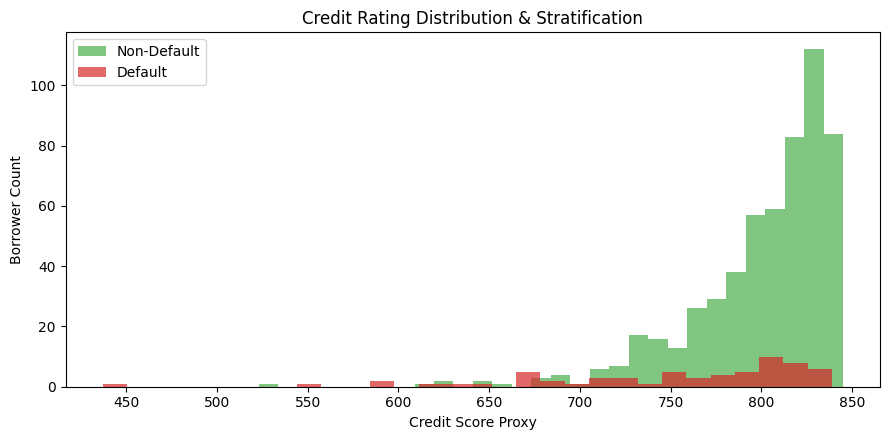

Total Exposure Tested: $15,361,892.94
Total Provisioning Required (Expected Loss): $688,734.13
Book Expected Loss Rate: 4.48%


In [3]:
import matplotlib.pyplot as plt

test_df = df_credit.loc[X_test.index].copy()
test_df['Estimated_PD'] = y_pred_pd

# Basel Expected Loss Formula: EL = PD * LGD * EAD
LGD = 0.45  # Loss Given Default (standard senior unsecured benchmark: 45%)
test_df['EAD'] = test_df['Loan_Amount']  # Exposure at Default
test_df['Expected_Loss'] = test_df['Estimated_PD'] * LGD * test_df['EAD']

# Credit Score Transformation (Scaled 300 to 850)
test_df['FICO_Proxy'] = (850 - (test_df['Estimated_PD'] * 550)).astype(int)

# Plot Risk Stratification
plt.figure(figsize=(9, 4.5))
plt.hist(test_df[test_df['Default_Flag'] == 0]['FICO_Proxy'], bins=30, alpha=0.6, label='Non-Default', color='#2ca02c')
plt.hist(test_df[test_df['Default_Flag'] == 1]['FICO_Proxy'], bins=30, alpha=0.7, label='Default', color='#d62728')
plt.title('Credit Rating Distribution & Stratification')
plt.xlabel('Credit Score Proxy')
plt.ylabel('Borrower Count')
plt.legend()
plt.tight_layout()
plt.savefig('credit_score_stratification.png')
plt.show()

total_book_ead = test_df['EAD'].sum()
total_book_el = test_df['Expected_Loss'].sum()

print(f"Total Exposure Tested: ${total_book_ead:,.2f}")
print(f"Total Provisioning Required (Expected Loss): ${total_book_el:,.2f}")
print(f"Book Expected Loss Rate: {(total_book_el / total_book_ead):.2%}")